In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torchmetrics.classification import MulticlassAccuracy
from sklearn.model_selection import train_test_split
from torchmetrics.utilities.plot import plot_confusion_matrix
from torchmetrics.classification import MulticlassConfusionMatrix
from pathlib import Path

In [2]:
FILE_NAME = "Crop_Recommendation.csv"
df = pd.read_csv(FILE_NAME)

In [3]:
df.describe()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [4]:
df.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [6]:
X = df[["Nitrogen", "Phosphorus", "Potassium", "Temperature", "Humidity", "pH_Value", "Rainfall"]].values
y = df["Crop"].values

In [7]:
print(f"Example of X features:\n{X[:5]}\n")
print(f"Example of y labels:\n{y[:5]}\n")

Example of X features:
[[ 90.          42.          43.          20.87974371  82.00274423
    6.50298529 202.9355362 ]
 [ 85.          58.          41.          21.77046169  80.31964408
    7.03809636 226.6555374 ]
 [ 60.          55.          44.          23.00445915  82.3207629
    7.84020714 263.9642476 ]
 [ 74.          35.          40.          26.49109635  80.15836264
    6.9804009  242.8640342 ]
 [ 78.          42.          42.          20.13017482  81.60487287
    7.62847289 262.7173405 ]]

Example of y labels:
['Rice' 'Rice' 'Rice' 'Rice' 'Rice']



In [8]:
labelEncoder = LabelEncoder()
y_encoded = labelEncoder.fit_transform(y)
print(f"Example of encoded y labels:\n{y_encoded[:5]}\n")

Example of encoded y labels:
[20 20 20 20 20]



In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [10]:
y_test

array([15, 21, 17, 17,  0, 12,  0, 13, 14, 10,  2,  4, 19,  8,  4, 19,  0,
       11, 17, 15,  5, 17, 16, 17,  3,  8, 14, 16, 18, 20, 19, 13,  8, 10,
        8,  2,  8,  3,  3,  9, 17, 12,  2, 11, 14, 11, 18,  4, 15, 11,  2,
        5,  7, 14,  5,  9,  6,  0,  1,  2, 21,  4, 10, 16, 17, 18, 16, 20,
       15, 18, 15,  4,  8,  1,  2, 17,  1,  6, 21, 16,  5,  3, 20, 13, 16,
       12,  5, 13,  2, 19, 11, 13,  6, 17, 18, 13,  9,  5,  2, 10,  4, 20,
       16, 15, 21,  9, 21,  1, 18, 13,  1,  8,  6, 19, 18,  3, 11,  4, 19,
       20, 18,  7,  2,  4,  3,  2,  4, 11,  1, 13,  1,  9, 19,  3,  4, 16,
       18,  1,  1,  0,  9, 15, 14, 13,  4, 11,  0,  4,  9, 13, 14, 10, 21,
       14, 18, 18, 18,  9, 11,  8,  3,  0, 16,  6, 20,  4,  7, 10, 21,  7,
        7,  2, 19,  3,  4, 11, 10,  7, 21,  8,  5,  5,  9,  8, 13,  9,  1,
        9,  4, 17, 17, 14, 12, 19, 21,  9, 11,  0,  2,  3,  7,  7,  1,  6,
       20, 19, 14,  1,  8, 14, 11,  3,  3,  3,  0, 20,  9, 17,  5,  2,  9,
       12, 12,  4, 17,  0

In [11]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [12]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

torch.Size([1760, 7]) torch.Size([440, 7]) torch.Size([1760]) torch.Size([440])


In [13]:
class CropProposer(nn.Module):

    def __init__(self):
        super().__init__()

        self.linearLayers = nn.Sequential(
            nn.Linear(in_features=7, out_features=16),
            nn.ReLU(),
            nn.Linear(in_features=16, out_features=16),
            nn.ReLU(),
            nn.Linear(in_features=16, out_features=22)
        )

    def forward(self, x):
        return self.linearLayers(x)



In [14]:
model = CropProposer()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [15]:
accuracy = MulticlassAccuracy(num_classes=22)

In [16]:
epochs = 750

for epoch in range(epochs):

    model.train()
    y_logits = model(X_train)
    loss = loss_fn(y_logits, y_train)

    pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    acc = accuracy(pred, y_train) * 100



    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.inference_mode():

        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)

        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_acc = accuracy(test_pred, y_test) * 100

        if epoch % 25 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.4f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")


Epoch: 0 | Loss: 9.9271 | Accuracy: 4.55% | Test Loss: 9.7339 | Test Accuracy: 4.55%
Epoch: 25 | Loss: 4.2531 | Accuracy: 14.00% | Test Loss: 4.3139 | Test Accuracy: 12.20%
Epoch: 50 | Loss: 2.9341 | Accuracy: 22.17% | Test Loss: 2.9908 | Test Accuracy: 23.69%
Epoch: 75 | Loss: 2.4529 | Accuracy: 31.77% | Test Loss: 2.4880 | Test Accuracy: 31.03%
Epoch: 100 | Loss: 2.1898 | Accuracy: 33.31% | Test Loss: 2.2119 | Test Accuracy: 32.48%
Epoch: 125 | Loss: 1.9587 | Accuracy: 42.83% | Test Loss: 1.9768 | Test Accuracy: 43.40%
Epoch: 150 | Loss: 1.6977 | Accuracy: 52.62% | Test Loss: 1.7167 | Test Accuracy: 51.03%
Epoch: 175 | Loss: 1.4608 | Accuracy: 59.77% | Test Loss: 1.4829 | Test Accuracy: 57.37%
Epoch: 200 | Loss: 1.2577 | Accuracy: 67.42% | Test Loss: 1.2779 | Test Accuracy: 66.29%
Epoch: 225 | Loss: 1.0917 | Accuracy: 70.51% | Test Loss: 1.1103 | Test Accuracy: 70.48%
Epoch: 250 | Loss: 0.9526 | Accuracy: 74.07% | Test Loss: 0.9704 | Test Accuracy: 74.91%
Epoch: 275 | Loss: 0.8265 | 

In [17]:
cm = MulticlassConfusionMatrix(num_classes=22)
matrix = cm(test_pred, y_test)
print(matrix)

tensor([[23,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0],
        [ 0, 21,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0],
        [ 0,  0, 18,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  1,  0,  0,  0,  0,
          0,  0,  0,  0],
        [ 0,  0,  0, 26,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0],
        [ 0,  0,  0,  0, 27,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0],
        [ 0,  0,  0,  0,  0, 16,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0, 16,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0, 14,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  1,  0,  0, 18,  0,  0,  0,  0,  0,  0,  0,  0,  1,
          0,  0,  3,  0],
        [ 0,  0,  0,  0,  0,  0,  0, 

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

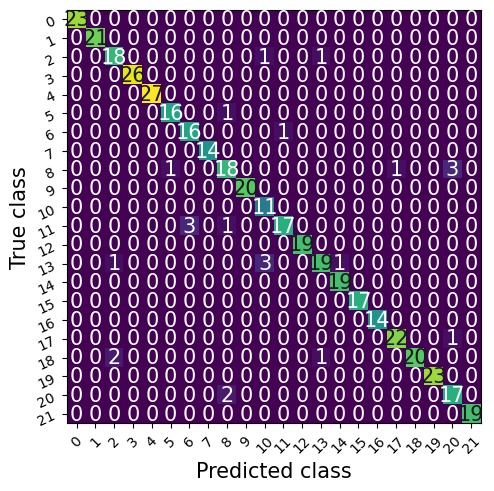

In [18]:
plot_confusion_matrix(matrix)

In [19]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

In [20]:
MODEL_NAME = "crop_recommendation_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

In [21]:
model.state_dict()

OrderedDict([('linearLayers.0.weight',
              tensor([[ 0.5761,  0.3813, -0.2475,  0.3948, -0.2948,  0.4283,  0.0073],
                      [-0.2697,  0.0020,  0.1888, -0.2417,  0.2893, -0.0778, -0.3636],
                      [ 0.0185,  0.0981, -0.2947, -0.3648,  0.1143, -0.3479, -0.3199],
                      [ 0.2152,  0.2437,  0.2614,  0.3579,  0.3115, -0.2052,  0.1272],
                      [ 0.2450,  0.0444,  0.2251, -0.1559, -0.3863, -0.4886,  0.3582],
                      [-0.3510, -0.0867, -0.3176,  0.2856, -0.1041,  0.3075, -0.1062],
                      [ 0.0981, -0.2652, -0.3214, -0.1352,  0.0826,  0.1296, -0.3552],
                      [-0.0336, -0.0987, -0.1834, -0.1390,  0.1394, -0.1200, -0.2260],
                      [ 0.0805, -0.4111,  0.2037,  0.2844, -0.1858,  0.1224,  0.2884],
                      [-0.0963,  0.5572,  0.1509, -0.0438, -0.4370,  0.2012,  0.2949],
                      [-0.1907,  0.2424,  0.3837,  0.3901, -0.3139,  0.2508,  0.0767],
    

In [22]:
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

In [23]:
new_sample = np.array([[72, 60, 25, 18.52510753, 69.0276233, 5.773454729, 88.10234397]])
new_sample_tensor = torch.tensor(new_sample, dtype=torch.float32)
